# 09 — Feature engineering + ablation (exploratory)

Turn the four business feature groups of fraud detection into concrete columns, then run an **ablation study** (drop groups/features and watch the metric move) to learn which signal is *real*. Metric of record: **PR-AUC** (fraud is rare; accuracy is meaningless).

> **This is an exploratory learning surface, not the promotable path.** The rigorous, manifest-backed ablation runs through `src/pit_fintech/training/` (plan Day 3). Here we explore quickly in-notebook. Heavy work is gated behind `RUN_ABLATION` so notebook verification stays fast and output-free (AGENTS §13).

## The one rule that reframes everything: PIT-safe vs leakage
Half of the 'obvious' fraud features are **post-outcome leakage** — they encode what happened *after* the transaction, so they cannot exist at scoring time. Building a deployable model on them is the classic trap. This notebook keeps them only as a labelled **non-deployable control** (like the Gold E2 control) to *prove* why they are excluded (project hard-rule #6).

### The four groups mapped onto this project

| Group (business) | Example features | Status here |
|---|---|---|
| 1 · Balance inconsistency | `error_balance_orig/dest`, `is_emptied_orig`, `is_zero_dest_before` | ❌ **LEAKAGE** — derived from the forbidden balance columns; control arm only |
| 2 · Ratio / normalised | `amount_to_oldbalance_ratio` | ❌ leakage (uses `oldbalanceOrg`) |
| 2 · Ratio / normalised | `amount_to_avg_history_ratio` | ✅ **PIT-safe** — built from the PIT history aggregates, engineered below |
| 3 · Velocity / aggregation (PIT) | `tx_count_1h/24h/168h`, `total_amount_1h/24h` | ✅ **already built & correct** = the 12 `paysim-fraud-recipient-v2` features in Gold; reused as-is |
| 4 · Graph / recipient | `is_new_recipient`, `recipient_has_history` | ✅ already in the 12 |
| 4 · Graph / recipient | `recipient_distinct_senders_1h`, `time_since_last_tx` | 🔎 **new PIT-safe candidate** — needs FeatureSpec v3 + backfill (Track B), out of scope this week |

**Why reuse Gold instead of recomputing velocity here:** a naive per-entity rolling count in a notebook silently reads future rows (leakage). The Gold `pre_decision_features` table already computes those windows strictly before each event's cutoff — so we join those exact columns rather than re-derive them.

📖 **Cell dưới — Setup & kiểm tra dữ liệu.** Import; resolve đường dẫn PaySim CSV, bảng Gold `pre_decision_features`, và Silver `paysim_labels` (qua manifest lakehouse). In ra dict `READY`: cả 4 khoá `True` nghĩa là đủ dữ liệu để chạy. Không train gì ở đây — chỉ định vị dữ liệu và tính sẵn các danh sách feature: `STATIC` = 3 biến request-time, `PIT12` = 12 feature, `HIST` = 9 feature lịch sử, `WIN_1H/24H/168H` = nhóm theo cửa sổ, `RECIP_FLAGS` = các cờ recipient.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

from pit_fintech.config import get_settings
from pit_fintech.data.paysim import (
    connect_paysim,
    find_paysim_csv,
    resolve_project_root,
)
from pit_fintech.features.paysim_specs import (
    PAYSIM_MODEL_FEATURE_ORDER,
    PAYSIM_STATIC_FEATURE_NAMES,
)

STATIC = list(PAYSIM_STATIC_FEATURE_NAMES)
PIT12 = list(PAYSIM_MODEL_FEATURE_ORDER)
HIST = [f for f in PIT12 if f not in STATIC]
WIN_1H = [f for f in HIST if f.endswith("_1h")]
WIN_24H = [f for f in HIST if f.endswith("_24h")]
WIN_168H = [f for f in HIST if f.endswith("_168h")]
RECIP_FLAGS = [f for f in HIST if f.startswith("recipient_has_history")]

PROJECT_ROOT = resolve_project_root(Path.cwd())
settings = get_settings()
data_root = settings.data_root
if not data_root.is_absolute():
    data_root = PROJECT_ROOT / data_root
artifact_root = settings.artifact_root
if not artifact_root.is_absolute():
    artifact_root = PROJECT_ROOT / artifact_root

paysim_csv = find_paysim_csv(PROJECT_ROOT)
gold_base = data_root / "lakehouse" / "paysim1"
gold_candidates = (
    sorted(gold_base.glob("*/gold/pre_decision_features")) if gold_base.exists() else []
)
GOLD_PRE_PATH = next((p for p in gold_candidates if (p / "_delta_log").exists()), None)

# Silver labels path via the lakehouse manifest (same resolution as notebooks 06/07).
LABELS_PATH = None
try:
    from pit_fintech.data.paysim_lakehouse import (
        ApplicationLakehouseManifest,
        _resolve_manifest_path,
        find_latest_paysim_lakehouse_manifest,
    )

    manifest_path = find_latest_paysim_lakehouse_manifest(artifact_root)
    if manifest_path is not None:
        manifest = ApplicationLakehouseManifest.model_validate_json(
            manifest_path.read_text(encoding="utf-8")
        )
        for snap in manifest.tables:
            if snap.table == "paysim_labels":
                LABELS_PATH = _resolve_manifest_path(snap.path, PROJECT_ROOT)
                break
except Exception as exc:  # optional context, never a gate
    print(f"label resolution skipped: {exc}")

READY = (
    paysim_csv is not None
    and GOLD_PRE_PATH is not None
    and LABELS_PATH is not None
    and (LABELS_PATH / "_delta_log").exists()
)
print(
    {
        "paysim_csv": paysim_csv is not None,
        "gold_pre": GOLD_PRE_PATH is not None,
        "labels": LABELS_PATH is not None,
        "ready": READY,
    }
)
if not READY:
    display(
        Markdown(
            "> **Not ready.** This notebook needs the PaySim CSV, a committed Gold "
            "`pre_decision_features`, and Silver `paysim_labels`. Build the lakehouse + Gold first."
        )
    )

{'paysim_csv': True, 'gold_pre': True, 'labels': True, 'ready': True}


## Execution control
Loading Gold + labels + raw and training ~8 models is opt-in. Keep `RUN_ABLATION = False` for fast, output-free verification; set it to `True` interactively to run the study.

In [2]:
RUN_ABLATION = True
SEED = 20_260_727

## Part A · Feature engineering
Assemble one table joined by `source_row_number`: the request-time columns, the 12 correct PIT features (from Gold), the raw balance columns (for the leakage control), and the label. Then engineer the derived columns — clearly tagging which are PIT-safe and which are leakage.

📖 **Cell dưới — Nạp & join dữ liệu thành 1 bảng `frame`.** Dùng DuckDB join theo `source_row_number`: 12 cột PIT từ Gold + nhãn `isFraud` từ Silver + 5 cột raw (`amount` và 4 cột số dư — chỉ để dựng arm leakage). In ra tổng số dòng và số fraud (≈ 0.3% — cực mất cân bằng, nên mới dùng PR-AUC). `frame` là bảng gốc cho mọi arm phía sau; nếu `RUN_ABLATION=False` thì `frame=None` và mọi cell sau tự bỏ qua.

In [3]:
frame = None
if RUN_ABLATION and READY:
    from deltalake import DeltaTable

    gold = DeltaTable(str(GOLD_PRE_PATH)).to_pyarrow_table()
    labels = (
        DeltaTable(str(LABELS_PATH)).to_pyarrow_table().select(["source_row_number", "isFraud"])
    )
    connection = connect_paysim(paysim_csv)  # DuckDB view `paysim` over the raw CSV
    connection.register("gold", gold)
    connection.register("labels", labels)
    pit_cols = ", ".join(f"g.{name}" for name in PIT12)
    frame = connection.execute(
        f"SELECT g.source_row_number, g.step, l.isFraud, {pit_cols}, "
        "p.amount, p.oldbalanceOrg, p.newbalanceOrig, p.oldbalanceDest, p.newbalanceDest "
        "FROM gold AS g "
        "JOIN labels AS l USING (source_row_number) "
        "JOIN paysim AS p USING (source_row_number) "
        "ORDER BY g.source_row_number"  # deterministic row order -> reproducible LightGBM bins
    ).df()
    connection.close()
    frame[PIT12] = frame[PIT12].astype("float64")
    print(f"rows={len(frame):,}  fraud={int(frame['isFraud'].sum()):,}")
else:
    print("Skipped: set RUN_ABLATION = True (and ensure data is ready).")

rows=2,770,409  fraud=8,213


📖 **Cell dưới — Engineer feature mới (thêm cột vào `frame`).** Từ 12 cột PIT + `current_amount`, tạo 8 biến **PIT-safe** trong `NEW_PIT_SAFE` (ratio số tiền/trung bình, trung bình gần đây, burst-ratio, gia tốc nhịp, cờ recipient mới) — dùng helper `_safe_div` để chia an toàn (mẫu ≤ 0 → trả 0). Đồng thời tạo 4 biến **LEAKAGE** trong `LEAK_FEATURES` từ cột số dư (chỉ làm control, KHÔNG deploy). `describe()` in phân bố để mắt thường soi (chú ý: các biến leakage đã 'ám' kết cục fraud).

In [4]:
# --- PIT-safe engineered features: pure transforms of the 12 PIT columns + current_amount.
# All are computable at scoring time from the same inputs -> contract-safe, no backfill.
NEW_PIT_SAFE = [
    "amount_to_avg_recipient_ratio",
    "avg_prior_amount_1h",
    "avg_prior_amount_24h",
    "amount_vs_recent_avg_1h",
    "burst_ratio_1h_24h",
    "burst_ratio_24h_168h",
    "count_acceleration",
    "is_new_recipient",
]
# Leakage features (from forbidden balance columns) -- CONTROL ARM ONLY, never deployed.
LEAK_FEATURES = [
    "error_balance_orig",
    "error_balance_dest",
    "is_emptied_orig",
    "is_zero_dest_before",
]


def _safe_div(numerator, denominator):
    """Elementwise divide, returning 0 where the denominator is not positive."""
    return (numerator / denominator).where(denominator > 0, other=0.0)


if frame is not None:
    avg_1h = _safe_div(frame["pit_prior_amount_1h"], frame["pit_prior_count_1h"])
    avg_24h = _safe_div(frame["pit_prior_amount_24h"], frame["pit_prior_count_24h"])
    avg_168h = _safe_div(frame["pit_prior_amount_168h"], frame["pit_prior_count_168h"])
    frame["avg_prior_amount_1h"] = avg_1h
    frame["avg_prior_amount_24h"] = avg_24h
    frame["amount_to_avg_recipient_ratio"] = _safe_div(frame["current_amount"], avg_168h)
    frame["amount_vs_recent_avg_1h"] = _safe_div(frame["current_amount"], avg_1h)
    frame["burst_ratio_1h_24h"] = _safe_div(
        frame["pit_prior_count_1h"], frame["pit_prior_count_24h"]
    )
    frame["burst_ratio_24h_168h"] = _safe_div(
        frame["pit_prior_count_24h"], frame["pit_prior_count_168h"]
    )
    frame["count_acceleration"] = frame["pit_prior_count_1h"] - frame["pit_prior_count_24h"] / 24.0
    frame["is_new_recipient"] = (1 - frame["recipient_has_history_168h"]).astype("int64")
    # Leakage control columns (row-local; encode the post-transaction outcome).
    frame["error_balance_orig"] = frame["oldbalanceOrg"] - frame["amount"] - frame["newbalanceOrig"]
    frame["error_balance_dest"] = (
        frame["oldbalanceDest"] + frame["amount"] - frame["newbalanceDest"]
    )
    frame["is_emptied_orig"] = (
        (frame["newbalanceOrig"] == 0) & (frame["oldbalanceOrg"] > 0)
    ).astype("int64")
    frame["is_zero_dest_before"] = (frame["oldbalanceDest"] == 0).astype("int64")
    display(frame[[*NEW_PIT_SAFE, *LEAK_FEATURES]].describe().round(3))
else:
    print("Skipped: enable RUN_ABLATION above.")

,amount_to_avg_recipient_ratio,avg_prior_amount_1h,avg_prior_amount_24h,amount_vs_recent_avg_1h,burst_ratio_1h_24h,burst_ratio_24h_168h,count_acceleration,is_new_recipient,error_balance_orig,error_balance_dest,is_emptied_orig,is_zero_dest_before
count,2770409.000,2.770409e+06,2.770409e+06,2770409.000,2770409.000,2770409.000,2770409.000,2770409.000,2.770409e+06,2.770409e+06,2770409.000,2770409.000
mean,2.708,3.448021e+04,1.585931e+05,1.221,0.064,0.290,0.115,0.177,-2.859850e+05,-2.864713e+04,0.429,0.141
std,129.900,2.697069e+05,5.464020e+05,251.842,0.209,0.374,0.593,0.381,8.753230e+05,5.934794e+05,0.495,0.348
min,0.000,0.000000e+00,0.000000e+00,0.000,0.000,0.000,-3.542,0.000,-9.244552e+07,-7.588573e+07,0.000,0.000
25%,0.138,0.000000e+00,0.000000e+00,0.000,0.000,0.000,-0.042,0.000,-2.798912e+05,0.000000e+00,0.000,0.000
50%,0.636,0.000000e+00,5.816157e+04,0.000,0.000,0.111,0.000,0.000,-1.435971e+05,0.000000e+00,0.000,0.000
75%,1.483,0.000000e+00,2.083625e+05,0.000,0.000,0.500,0.000,0.000,-5.185310e+04,0.000000e+00,1.000,0.000
max,89618.817,9.244552e+07,9.244552e+07,349001.172,1.000,1.000,30.667,1.000,1.000000e-02,1.000000e+07,1.000,1.000


### 📖 Các biến MỚI vừa tạo

**PIT-safe (dùng được, chỉ biến đổi từ 12 feature PIT + `current_amount`):**
- `amount_to_avg_recipient_ratio` — số tiền hiện tại gấp mấy lần **trung bình 7 ngày** của người nhận. Lớn bất thường = 'sốc'.
- `avg_prior_amount_1h`, `avg_prior_amount_24h` — số tiền **trung bình gần đây** của người nhận (`amount / count` theo cửa sổ).
- `amount_vs_recent_avg_1h` — giao dịch hiện tại so với trung bình 1h.
- `burst_ratio_1h_24h`, `burst_ratio_24h_168h` — hoạt động có **dồn** vào cửa sổ ngắn không (bắt burst/bot).
- `count_acceleration` — nhịp 1h gần nhất trừ nhịp trung bình mỗi giờ trong 24h.
- `is_new_recipient` — `1 − recipient_has_history_168h` (cờ người nhận mới).

Tất cả **chỉ dùng dữ liệu trước cutoff** → an toàn lúc scoring, không cần backfill.

**LEAKAGE (chỉ làm control, KHÔNG deploy):** `error_balance_*`, `is_emptied_orig`, `is_zero_dest_before` — tính từ số dư *sau* giao dịch (hoặc artifact số dư của PaySim). Ở bảng `describe` chúng gần như 'chỉ điểm' fraud vì đã biết kết cục — đúng định nghĩa leakage.

## Part B · Ablation study
The ladder: **baseline** (request-time only) → **+ PIT** (the 12) → **group-wise** removals (drop each window / the recipient flags) → **+ PIT-safe ratio** → **leakage control** (the disqualified ceiling). Each arm trains one LightGBM with `scale_pos_weight` for imbalance and reports PR-AUC / ROC-AUC on the frozen temporal test split (step > 631).

📖 **Cell dưới — Khai báo các 'arm' của ablation.** `FEATURE_SETS` là dict `{tên arm → danh sách feature}`: baseline (3 biến) → +12 PIT → bỏ từng cửa sổ/nhóm recipient → +toàn bộ safe FE → control leakage. `LEAKAGE_SETS` đánh dấu arm nào **bị loại** (không deployable) để hàm eval gắn cờ `deployable=False`. Cell này chỉ *định nghĩa danh sách*, chưa train gì.

In [5]:
FEATURE_SETS = {
    "0 · baseline (request-time)": STATIC,
    "1 · + PIT (the 12) = E4": PIT12,
    "2 · PIT drop 1h window": [f for f in PIT12 if f not in WIN_1H],
    "2 · PIT drop 24h window": [f for f in PIT12 if f not in WIN_24H],
    "2 · PIT drop 168h window": [f for f in PIT12 if f not in WIN_168H],
    "2 · PIT drop recipient flags": [f for f in PIT12 if f not in RECIP_FLAGS],
    "3 · PIT + all safe FE": [*PIT12, *NEW_PIT_SAFE],
    "X · LEAKAGE control (balance)": [*STATIC, *LEAK_FEATURES],
}
LEAKAGE_SETS = {"X · LEAKAGE control (balance)"}

📖 **Cell dưới — Hàm `train_eval`: 'động cơ' của cả notebook.** Nhận (tên arm, danh sách feature, dữ liệu) → chia **train `step ≤ 520`** / **test `step > 631`** (chừa đệm 521–631 tránh rò rỉ ở biên) → train 1 LightGBM với `scale_pos_weight = neg/pos` để bù mất cân bằng → trả về PR-AUC & ROC-AUC *trên test*. Mọi bảng bên dưới đều gọi lại hàm này. Cell chỉ *định nghĩa hàm*, chưa chạy. (Lưu ý phương pháp: 1 seed, không cross-validation → đọc kết quả theo *hướng*, delta cỡ ±0.001–0.005 nằm trong nhiễu.)

In [6]:
def train_eval(name, features, data):
    """Train one exploratory LightGBM on the frozen temporal split; return test metrics."""
    from pit_fintech.models.paysim_lightgbm import _load_training_dependencies

    deps = _load_training_dependencies()
    train = data[data["step"] <= 520]
    test = data[data["step"] > 631]
    pos = int((train["isFraud"] == 1).sum())
    neg = int((train["isFraud"] == 0).sum())
    model = deps.lightgbm.LGBMClassifier(
        objective="binary",
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=50,
        scale_pos_weight=neg / max(pos, 1),
        deterministic=True,
        force_row_wise=True,  # LightGBM docs: pair with deterministic for stable results across threads
        seed=SEED,
        n_jobs=-1,
        verbose=-1,
    )
    model.fit(train[features], train["isFraud"])
    scores = model.predict_proba(test[features])[:, 1]
    return {
        "feature_set": name,
        "n_features": len(features),
        "pr_auc": round(float(deps.average_precision_score(test["isFraud"], scores)), 6),
        "roc_auc": round(float(deps.roc_auc_score(test["isFraud"], scores)), 6),
        "deployable": name not in LEAKAGE_SETS,
    }

📖 **Cell dưới — Chạy toàn bộ ablation chính.** Gọi `train_eval` cho từng arm trong `FEATURE_SETS`, gom vào bảng `results` sắp theo PR-AUC giảm dần. Đây là **bảng kết quả chính** (8 dòng) — cách đọc chi tiết ở markdown ngay sau biểu đồ.

In [7]:
results = None
if frame is not None:
    rows = [train_eval(name, feats, frame) for name, feats in FEATURE_SETS.items()]
    results = pd.DataFrame(rows).sort_values("pr_auc", ascending=False).reset_index(drop=True)
    display(results)
else:
    print("Skipped: enable RUN_ABLATION above.")

C:\workspace\pit-fintech\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,feature_set,n_features,pr_auc,roc_auc,deployable
0,X · LEAKAGE control (balance),7,0.882713,0.980490,False
1,2 · PIT drop recipient flags,9,0.068007,0.733878,True
2,2 · PIT drop 1h window,9,0.050573,0.665291,True
3,0 · baseline (request-time),3,0.047626,0.647857,True
4,1 · + PIT (the 12) = E4,12,0.045054,0.634301,True
5,2 · PIT drop 24h window,9,0.038923,0.578328,True
6,2 · PIT drop 168h window,9,0.038521,0.573590,True
7,3 · PIT + all safe FE,20,0.036337,0.547897,True


📖 **Cell dưới — Vẽ biểu đồ ablation.** Bar ngang PR-AUC theo arm: **cột đỏ = arm leakage** (bị loại), **cột xanh = deployable**. Chỉ trực quan hoá lại bảng `results`, không tính thêm gì. `matplotlib` là optional — thiếu thì in cảnh báo, bảng ở trên vẫn là kết quả.

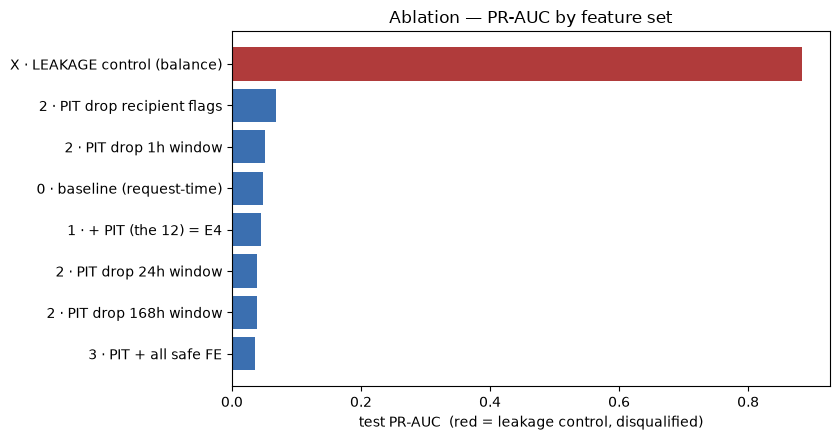

In [8]:
if results is not None:
    try:
        import matplotlib.pyplot as plt

        order = results.sort_values("pr_auc")
        colors = ["#b03b3b" if not d else "#3b6fb0" for d in order["deployable"]]
        fig, ax = plt.subplots(figsize=(8.5, 4.5))
        ax.barh(range(len(order)), order["pr_auc"], color=colors)
        ax.set_yticks(range(len(order)), labels=order["feature_set"])
        ax.set_xlabel("test PR-AUC  (red = leakage control, disqualified)")
        ax.set_title("Ablation — PR-AUC by feature set")
        fig.tight_layout()
        plt.show()
    except ImportError:
        print("matplotlib unavailable; table above is the result.")
else:
    print("Skipped: enable RUN_ABLATION above.")

### 📖 Cách đọc bảng/biểu đồ ablation
- **PR-AUC là thước đo chính** (cao hơn = tốt hơn); ROC-AUC để tham khảo.
- **Cột đỏ = arm LEAKAGE** — gần như chắc chắn đứng đầu, nhưng **bị loại** vì dùng dữ liệu sau giao dịch. Đây là 'trần gian lận', KHÔNG phải mục tiêu. Bài học: điểm cao chưa chắc hợp lệ.
- So **`baseline` → `+ PIT`**: PIT nâng được bao nhiêu = giá trị thật của 12 feature lịch sử.
- **Group-wise** (`drop 1h/24h/168h`, `drop recipient flags`): PR-AUC tụt nhiều nhất khi bỏ nhóm nào → nhóm đó tải tín hiệu mạnh nhất. Tụt gần như không đáng kể → nhóm đó gần như thừa.
- `+ all safe FE`: cả gói biến PIT-safe mới có thêm được gì so với PIT (chi tiết từng biến ở bảng additive bên dưới).
- **Nối với heatmap (notebook 07/08):** các feature tương quan cao (has_history vs count; window lồng nhau) thường bỏ đi mà PR-AUC ít đổi — đó là *feature-wise ablation* để làm model gọn.

### So sánh: biến MỚI nào thực sự thêm tín hiệu?
Thêm **từng** biến PIT-safe mới lên trên PIT12 rồi đo lại PR-AUC. Đây là câu trả lời trực tiếp cho 'biến nào phù hợp với dataset':
- `delta_vs_pit` **dương và lớn** = biến đó **đáng thêm**.
- `delta_vs_pit` **≈ 0 hoặc âm** = không giúp (thường vì trùng thông tin với 12 feature sẵn có — xem heatmap notebook 07).

In [9]:
# Which NEW PIT-safe feature actually adds signal? Add each one alone on top of PIT12.
additive = None
if frame is not None:
    base_pr = train_eval("pit_full", PIT12, frame)["pr_auc"]
    rows = []
    for feat in NEW_PIT_SAFE:
        pr = train_eval(f"+{feat}", [*PIT12, feat], frame)["pr_auc"]
        rows.append({"added_feature": feat, "pr_auc": pr, "delta_vs_pit": round(pr - base_pr, 6)})
    additive = (
        pd.DataFrame(rows).sort_values("delta_vs_pit", ascending=False).reset_index(drop=True)
    )
    print(f"pit_full PR-AUC = {base_pr:.6f}")
    display(additive)
else:
    print("Skipped: enable RUN_ABLATION above.")

pit_full PR-AUC = 0.045054


,added_feature,pr_auc,delta_vs_pit
0,avg_prior_amount_24h,0.050669,0.005615
1,is_new_recipient,0.045054,0.000000
2,burst_ratio_1h_24h,0.042794,-0.002260
3,amount_to_avg_recipient_ratio,0.042498,-0.002556
4,amount_vs_recent_avg_1h,0.040527,-0.004527
5,count_acceleration,0.039624,-0.005430
6,burst_ratio_24h_168h,0.037725,-0.007329
7,avg_prior_amount_1h,0.037572,-0.007482


### 12 biến PIT cũ — mỗi biến đóng góp bao nhiêu?
Trước đây ta xây 12 feature PIT mà **chưa** kiểm định từng cái (nên hơi 'bựa'). Bù lại ở đây: mỗi feature lịch sử được thêm **đơn lẻ** lên baseline request-time, xem nó tự mình nâng PR-AUC bao nhiêu. `lift_vs_baseline` lớn = feature khỏe; ≈ 0 = gần vô dụng khi đứng một mình (vẫn có thể hữu ích khi kết hợp — đối chiếu bảng drop bên dưới).

In [10]:
# The 12 old PIT features get the same treatment: each history feature's standalone lift over
# the request-time baseline (the 3 static features ARE that baseline).
old_additive = None
if frame is not None:
    base_req = train_eval("baseline", STATIC, frame)["pr_auc"]
    rows = []
    for feat in HIST:
        pr = train_eval(f"+{feat}", [*STATIC, feat], frame)["pr_auc"]
        rows.append(
            {"pit_feature": feat, "pr_auc": pr, "lift_vs_baseline": round(pr - base_req, 6)}
        )
    old_additive = (
        pd.DataFrame(rows).sort_values("lift_vs_baseline", ascending=False).reset_index(drop=True)
    )
    print(f"baseline (request-time) PR-AUC = {base_req:.6f}")
    display(old_additive)
else:
    print("Skipped: enable RUN_ABLATION above.")

baseline (request-time) PR-AUC = 0.047626


,pit_feature,pr_auc,lift_vs_baseline
0,pit_prior_amount_1h,0.048279,0.000653
1,pit_prior_amount_24h,0.045988,-0.001638
2,pit_prior_count_168h,0.042355,-0.005271
3,pit_prior_count_24h,0.038368,-0.009258
4,recipient_has_history_168h,0.037262,-0.010364
5,pit_prior_amount_168h,0.035634,-0.011992
6,recipient_has_history_24h,0.035330,-0.012296
7,recipient_has_history_1h,0.033536,-0.014090
8,pit_prior_count_1h,0.033337,-0.014289


### Leave-one-out trên toàn bộ 12 feature
Bỏ **từng** feature (cả 3 static lẫn 9 lịch sử) khỏi bộ đầy đủ, đo PR-AUC tụt bao nhiêu.

In [11]:
# Feature-wise ablation: drop each of the 12 features alone, measure the PR-AUC delta.
feature_wise = None
if frame is not None:
    base = train_eval("pit_full", PIT12, frame)["pr_auc"]
    rows = []
    for feat in PIT12:
        reduced = [f for f in PIT12 if f != feat]
        pr = train_eval(f"drop {feat}", reduced, frame)["pr_auc"]
        rows.append({"dropped_feature": feat, "pr_auc": pr, "delta_vs_full": round(pr - base, 6)})
    feature_wise = pd.DataFrame(rows).sort_values("delta_vs_full").reset_index(drop=True)
    print(f"pit_full PR-AUC = {base:.6f}")
    display(feature_wise)
else:
    print("Skipped: enable RUN_ABLATION above.")

pit_full PR-AUC = 0.045054


,dropped_feature,pr_auc,delta_vs_full
0,current_amount,0.033812,-0.011242
1,pit_prior_amount_24h,0.034264,-0.010790
2,transaction_type_transfer,0.034762,-0.010292
3,pit_prior_count_1h,0.038455,-0.006599
4,pit_prior_amount_1h,0.039228,-0.005826
5,pit_prior_amount_168h,0.039543,-0.005511
6,pit_prior_count_24h,0.041139,-0.003915
7,recipient_has_history_1h,0.045054,0.000000
8,recipient_has_history_168h,0.045054,0.000000
9,pit_prior_count_168h,0.048055,0.003001


### 📖 Cách đọc feature-wise
`delta_vs_full` = PR-AUC khi bỏ 1 feature trừ đi PR-AUC đầy đủ. **Âm nhiều** = bỏ feature đó làm model tệ đi rõ → feature quan trọng, **giữ**. **Gần 0 hoặc dương** = bỏ đi không hại (thậm chí đỡ nhiễu) → **ứng viên loại bỏ** để model gọn hơn (nhất là các feature đã thấy trùng thông tin trên heatmap). Lưu ý: bỏ *thật* một stored feature là contract v3 + ADR + backfill — ở đây chỉ mới *đo bằng chứng*, chưa bỏ.

## Part C · Kiểm chứng giả thuyết: `event_step` có gây overfit thời gian không?

Ở bảng leave-one-out phía trên, **bỏ đúng một feature `event_step` làm PR-AUC hơn gấp đôi** — không feature nào khác có tác động gần bằng (feature "độc" thứ nhì chỉ ở mức phần nghìn). Bất thường tới mức phải *điều tra bằng chứng* chứ không nhận bừa.

**Giả thuyết:** `event_step` là *chỉ số thời gian tuyệt đối*. Vì split theo thời gian (train `step ≤ 520`, test `step > 631`), model học pattern gắn với vùng step của train nhưng test nằm ở vùng step **khác hẳn** → model phải extrapolate một giá trị chưa từng thấy → dự đoán sai. Đây là cái bẫy feature thời gian tuyệt đối kinh điển, và nó *ngược* với mục tiêu PIT của dự án (feature phải tổng quát hoá sang tương lai).

Ba mẩu bằng chứng dưới đây kiểm định: (1) khoảng `event_step` train/test có chồng nhau không, (2) model dồn bao nhiêu *gain* vào `event_step`, (3) hệ quả trên PR-AUC.

In [12]:
# Part C probe: three pieces of evidence that event_step is absolute-time overfitting, not signal.
overfit_probe = None
if frame is not None:
    from pit_fintech.models.paysim_lightgbm import _load_training_dependencies

    deps = _load_training_dependencies()
    train = frame[frame["step"] <= 520]
    test = frame[frame["step"] > 631]

    # 1) Do train and test even share the same event_step values?
    tr_lo, tr_hi = int(train["event_step"].min()), int(train["event_step"].max())
    te_lo, te_hi = int(test["event_step"].min()), int(test["event_step"].max())
    overlap = max(0, min(tr_hi, te_hi) - max(tr_lo, te_lo))
    print(f"train event_step range = [{tr_lo}, {tr_hi}]")
    print(f"test  event_step range = [{te_lo}, {te_hi}]")
    print(
        f"overlap width = {overlap}  -> test values were NEVER seen in train (model extrapolates)\n"
    )

    # 2) Where does the full model spend its gain? Train once and rank importances.
    pos = int((train["isFraud"] == 1).sum())
    neg = int((train["isFraud"] == 0).sum())
    model = deps.lightgbm.LGBMClassifier(
        objective="binary",
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=50,
        scale_pos_weight=neg / max(pos, 1),
        deterministic=True,
        force_row_wise=True,  # same reproducibility pairing as train_eval
        seed=SEED,
        n_jobs=-1,
        verbose=-1,
    )
    model.fit(train[PIT12], train["isFraud"])
    gain = model.booster_.feature_importance(importance_type="gain")
    overfit_probe = (
        pd.DataFrame({"feature": PIT12, "gain": gain})
        .sort_values("gain", ascending=False)
        .reset_index(drop=True)
    )
    overfit_probe["gain_share"] = (overfit_probe["gain"] / overfit_probe["gain"].sum()).round(3)
    display(overfit_probe)

    # 3) The metric consequence, side by side.
    pr_full = train_eval("full 12", PIT12, frame)["pr_auc"]
    pr_drop = train_eval("drop event_step", [f for f in PIT12 if f != "event_step"], frame)[
        "pr_auc"
    ]
    print(f"\nPR-AUC full 12            = {pr_full:.6f}")
    print(f"PR-AUC without event_step = {pr_drop:.6f}   (delta {pr_drop - pr_full:+.6f})")
else:
    print("Skipped: enable RUN_ABLATION above.")

train event_step range = [1, 520]
test  event_step range = [632, 743]
overlap width = 0  -> test values were NEVER seen in train (model extrapolates)



,feature,gain,gain_share
0,current_amount,1.343309e+14,0.431
1,event_step,9.272259e+13,0.298
2,pit_prior_amount_168h,3.644069e+13,0.117
3,pit_prior_count_168h,2.119154e+13,0.068
4,pit_prior_amount_24h,2.071026e+13,0.067
5,pit_prior_count_24h,4.120908e+12,0.013
6,pit_prior_amount_1h,1.045312e+12,0.003
7,transaction_type_transfer,3.511967e+11,0.001
8,pit_prior_count_1h,3.205341e+11,0.001
9,recipient_has_history_24h,1.582005e+11,0.001



PR-AUC full 12            = 0.045054
PR-AUC without event_step = 0.092308   (delta +0.047254)


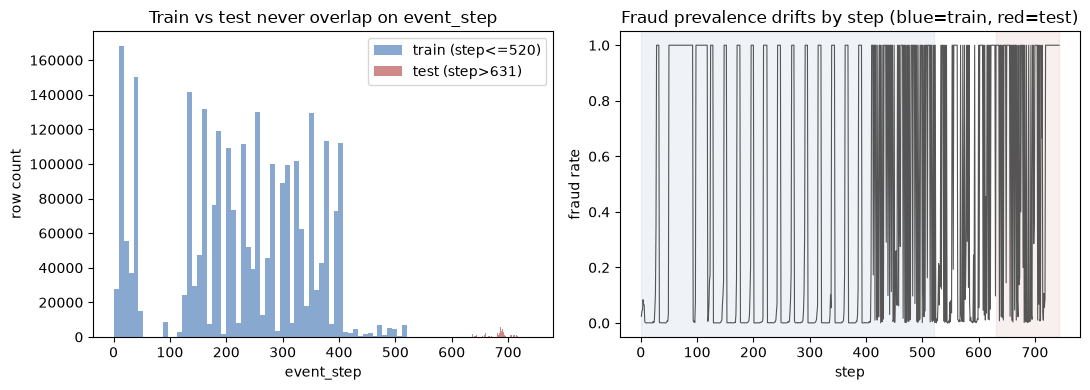

In [13]:
# Visual evidence: the train/test gap on event_step + how fraud prevalence drifts across steps.
if frame is not None:
    try:
        import matplotlib.pyplot as plt

        train = frame[frame["step"] <= 520]
        test = frame[frame["step"] > 631]
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

        ax1.hist(
            train["event_step"], bins=60, alpha=0.6, color="#3b6fb0", label="train (step<=520)"
        )
        ax1.hist(test["event_step"], bins=60, alpha=0.6, color="#b03b3b", label="test (step>631)")
        ax1.set_xlabel("event_step")
        ax1.set_ylabel("row count")
        ax1.set_title("Train vs test never overlap on event_step")
        ax1.legend()

        by_step = frame.groupby("step")["isFraud"].mean()
        ax2.plot(by_step.index, by_step.values, color="#555", lw=0.8)
        ax2.axvspan(0, 520, alpha=0.08, color="#3b6fb0")
        ax2.axvspan(631, float(frame["step"].max()), alpha=0.08, color="#b03b3b")
        ax2.set_xlabel("step")
        ax2.set_ylabel("fraud rate")
        ax2.set_title("Fraud prevalence drifts by step (blue=train, red=test)")

        fig.tight_layout()
        plt.show()
    except ImportError:
        print("matplotlib unavailable; the table + prints above are the evidence.")
else:
    print("Skipped: enable RUN_ABLATION above.")

### 📖 Cách đọc Part C
- **Range `event_step` (print):** nếu khoảng của test nằm *hoàn toàn* bên phải khoảng train (`overlap = 0`) → mọi giá trị `event_step` ở test là **chưa từng thấy** lúc train. Cây quyết định không split đúng trên giá trị chưa gặp → dấu hiệu kinh điển của *feature thời gian tuyệt đối*.
- **Bảng `gain_share`:** `event_step` chiếm tỷ trọng *gain* lớn = model **dựa nhiều** vào nó lúc train. Kết hợp với việc bỏ nó lại *cải thiện* test → model đang 'học thuộc' vùng step thay vì học tín hiệu gian lận tổng quát = **overfit thời gian**.
- **PR-AUC full vs drop (print):** bỏ `event_step` làm PR-AUC **hơn gấp đôi** — biên độ này quá lớn để là nhiễu (đối chiếu: các feature khác chỉ dịch ở mức phần nghìn).
- **Biểu đồ trái:** hai khối histogram train/test **tách rời** trên trục `event_step` = xác nhận không chồng lấn.
- **Biểu đồ phải:** tỷ lệ fraud **trôi** theo step (vùng xanh = train, đỏ = test). Prevalence hai vùng khác nhau giải thích vì sao học theo step tuyệt đối không tổng quát hoá.

**Hệ quả hành động:** loại `event_step` khỏi feature set deployable (nó là biến request-time, bỏ dễ, **không cần backfill**). Nếu vẫn cần tín hiệu thời gian, thay bằng biến *tương đối* (vd `time_since_last_tx`) — an toàn PIT và không phụ thuộc vùng step tuyệt đối. Đây là ứng viên số 1 để đưa vào ablation chính thức ở `training/`.

## Kết luận & bước tiếp
- **Tín hiệu thật vs leakage:** arm leakage thắng metric nhưng bị loại — đó là lý do dự án cấm 4 cột số dư. Model deployable chỉ được dùng feature PIT-safe.
- **Đóng góp theo nhóm:** group-wise cho biết cửa sổ nào (1h/24h/168h) và nhóm recipient tải tín hiệu mạnh nhất.
- **Gọn hoá:** feature-wise + heatmap chỉ ra feature trùng lặp có thể đề xuất bỏ (contract v3).
- **Candidate mới PIT-safe** (`time_since_last_tx`, `recipient_distinct_senders_1h`) chỉ mở khi ablation cho thấy 12 field là trần và còn buffer → Track B.

Kết quả ở đây là **exploratory**; bản ablation chính thức (có manifest, gate) chạy qua `training/run_candidate_matrix` theo plan Day 3.